/tmp/ipykernel_2369760/3727158033.py:26: UserWarning: 
The palette list has fewer values (5) than needed (6) and will cycle, which may produce an uninterpretable plot.
  ax = sns.boxplot(


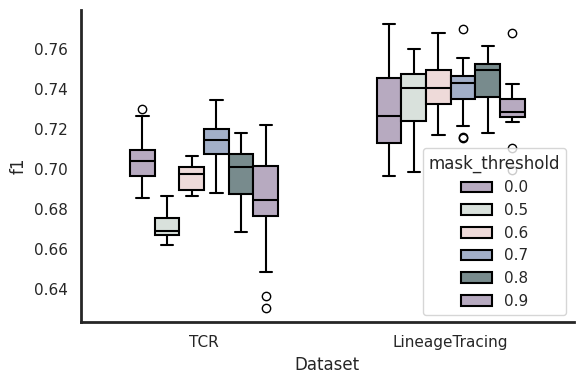

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df1 = pd.read_csv('../experiment/Fig2.tune.mask_threshold.CD8.csv')
df2 = pd.read_csv('../experiment/Fig2.tune.mask_threshold.lt.csv')

df1['Dataset'] = 'TCR'
df2['Dataset'] = 'LineageTracing'

df = pd.concat([df1, df2], ignore_index=True)

x_col = 'Dataset'   
y_col = 'f1'      
hue_col = 'mask_threshold'   

sns.set(style="white")

plt.figure(figsize=(6,4))
ax = sns.boxplot(
    x=x_col,
    y=y_col,
    hue=hue_col,
    data=df,
    palette=['#B8A6C4', '#D8E2DC','#F2D7D5','#9CADCE','#748E91'],
    width=0.6,
    linecolor='black',
    linewidth=1.5
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)

ax.tick_params(axis='x', direction='out', length=6, width=1.5)
ax.tick_params(axis='y', direction='out', length=6, width=1.5)


plt.tight_layout()
#plt.savefig(f"../experiment/{hue_col}_compare_{y_col}.pdf",bbox_inches='tight')
plt.show()

/tmp/ipykernel_2369760/2796568872.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_2369760/2796568872.py:22: UserWarning: 
The palette list has fewer values (5) than needed (6) and will cycle, which may produce an uninterpretable plot.
  ax = sns.boxplot(
/tmp/ipykernel_2369760/2796568872.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Dataset', loc='upper right')


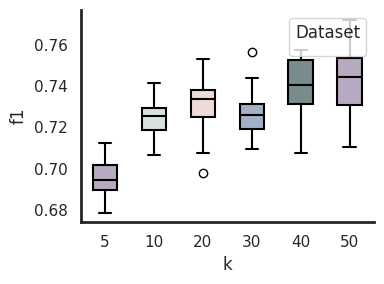

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dataset = 'lt'
hyperparam = 'k'
metric = 'f1'


df = pd.read_csv(f'../experiment/Fig2.tune.{hyperparam}.{dataset}.csv')


x_col = hyperparam   
y_col = metric     

sns.set(style="white")

plt.figure(figsize=(4,3))
ax = sns.boxplot(
    x=x_col,
    y=y_col,
    data=df,
    palette=['#B8A6C4', '#D8E2DC','#F2D7D5','#9CADCE','#748E91'],  
    width=0.5,
    linecolor='black',
    linewidth=1.5
)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)

ax.tick_params(axis='x', direction='out', length=6, width=1.5)
ax.tick_params(axis='y', direction='out', length=6, width=1.5)

plt.legend(title='Dataset', loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
import sys
import os
import pandas as pd
from pathlib import Path

sys.path.append(os.path.abspath("../src"))
from utils.metrics import calculate_fate_metrics

df1 = pd.read_csv('../experiment/Fig2.tune.cell_number.lt.new.csv')
df1 = df1.loc[:,['adata_path','auroc','acc','f1','pearson','spearman']]
df1['adata_path'] = df1['adata_path'].str.extract(r'(day\d+)')
df1['method'] = 'DyMoTree'


methods = ["WOT", "CoSpar", "CellRank", "Palantir", "FateID"]
days = ["day2", "day4", "day6"]

file_map = {
    "WOT": "wot.res.csv",
    "CoSpar": "cospar.res.csv",
    "CellRank": "cellrank.res.csv",
    "Palantir": "palantir.res.csv",
    "FateID": "fateid.res.csv"
}

base_dir = Path("../experiment/benchmark")

all_res = []

for method in methods:
    for day in days:
        file_path = base_dir / f"LT.{method}" / day / file_map[method]

        if not file_path.exists():
            continue

        res = pd.read_csv(file_path, index_col=0)
        if method == "WOT":
            res["fate_bias"] = res["Monocyte_fate"] / (
                res["Monocyte_fate"] + res["Neutrophil_fate"]
            )
            metric_dict = calculate_fate_metrics(
                y_true_prob=res["Weinreb_fate"],
                y_pred_prob=res["fate_bias"]
            )
        elif method == 'CoSpar':
            metric_dict = calculate_fate_metrics(
                y_true_prob=res["ground_truth"],
                y_pred_prob=1- res["fate_bias_transition_map_Neutrophil*Monocyte"]
            )
        else:
            metric_dict = calculate_fate_metrics(
                y_true_prob=res["ground_truth"],
                y_pred_prob=res["fate_bias"]
            )           
        tmp_df = pd.DataFrame([metric_dict])
        tmp_df["method"] = method
        tmp_df["adata_path"] = day

        all_res.append(tmp_df)

if all_res:
    batch_df = pd.concat(all_res, ignore_index=True)
    df1 = pd.concat([df1, batch_df], ignore_index=True)

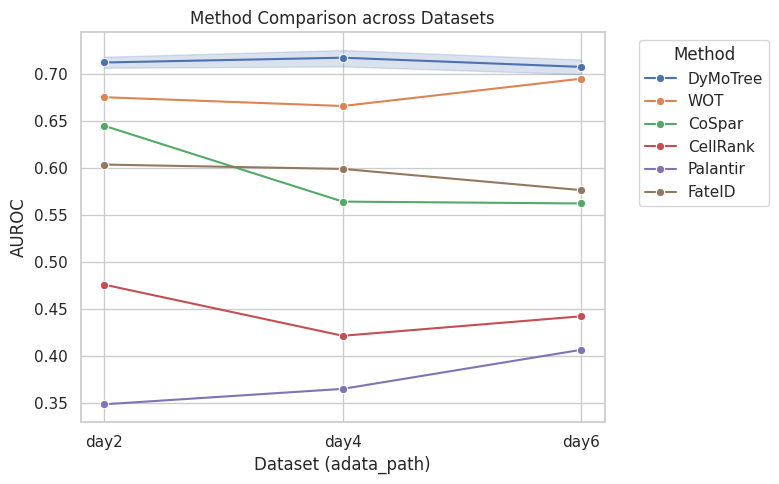

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=df1,
    x="adata_path",
    y="f1",       
    hue="method",
    marker="o"
)

plt.title("Method Comparison across Datasets")
plt.xlabel("Dataset (adata_path)")
plt.ylabel("AUROC")

plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

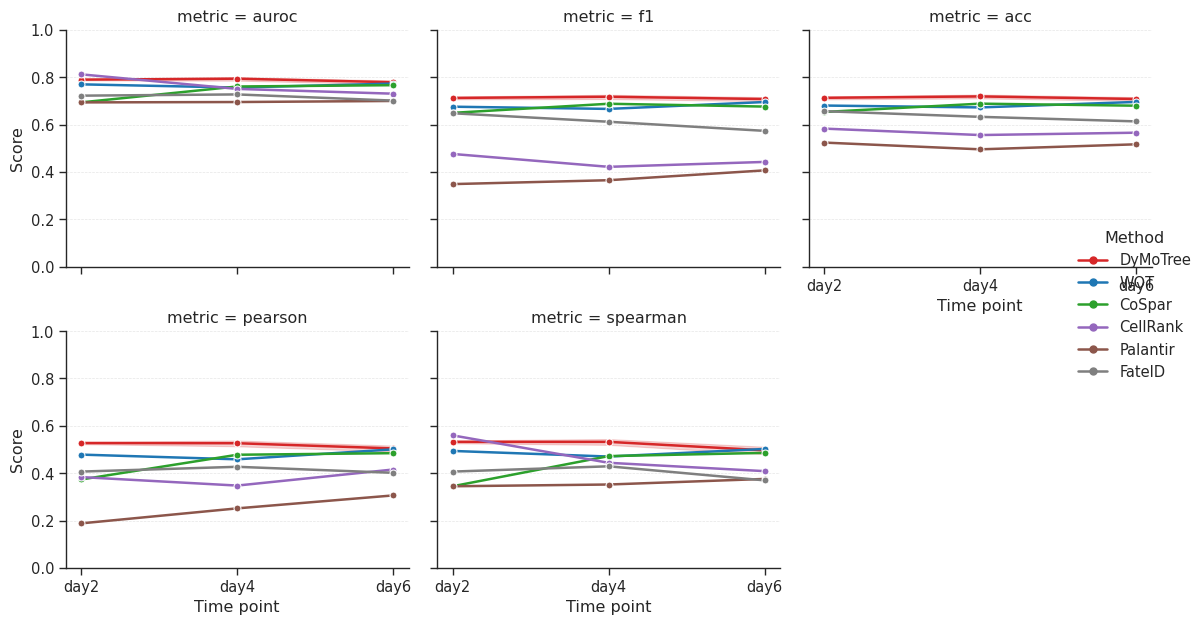

In [ ]:
df_long = df1.melt(
    id_vars=["method", "adata_path"],
    value_vars=["auroc", "acc", "f1", "pearson", "spearman"],
    var_name="metric",
    value_name="value"
)
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="ticks",
    context="paper",
    font_scale=1.2
)

palette = {
    "DyMoTree": "#D62728",   
    "WOT": "#1F77B4",
    "CoSpar": "#2CA02C",
    "CellRank": "#9467BD",
    "Palantir": "#8C564B",
    "FateID": "#7F7F7F"
}

metric_order = ["auroc", "f1", "acc", "pearson", "spearman"]

df_long["metric"] = pd.Categorical(
    df_long["metric"],
    categories=metric_order,
    ordered=True
)

g = sns.relplot(
    data=df_long,
    x="adata_path",
    y="value",
    hue="method",
    kind="line",
    marker="o",
    col="metric",
    col_wrap=3,
    height=3.2,
    aspect=1.1,
    palette=palette,
    linewidth=1.8,
    markersize=5
)

for ax in g.axes.flatten():
    sns.despine(ax=ax)

    ax.set_ylim(0, 1)

    ax.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.5)

g.set_axis_labels("Time point", "Score")

g._legend.set_title("Method")
g._legend.set_bbox_to_anchor((1.02, 0.5))
g._legend.set_frame_on(False)

plt.tight_layout()
#plt.savefig(f"../experiment/cellnumber_compare.png",bbox_inches='tight')
plt.show()

In [62]:
import sys
import os
sys.path.append(os.path.abspath("../src"))
import pandas as pd
from pathlib import Path
import scanpy as sc
from dmt import DyMoTree
import pandas as pd

from utils.metrics import calculate_fate_metrics

df1 = pd.read_csv('../experiment/Fig2.bench.lt.csv')
df1 = df1.loc[:,['adata_path','auroc','acc','f1','pearson','spearman']]
df1['adata_path'] = df1['adata_path'].str.extract(r'(day\d+)')
df1['method'] = 'DyMoTree'

adata = sc.read_h5ad("../data/bench/lt/day246/anndata/anndata.h5ad")
dmt = DyMoTree(adata=adata,
               k=50,
               progenitor='Undifferentiated',
               terminal=['Neutrophil','Monocyte'],
               lineage_col='Cell.type.annotation',
               emb_key='emb',
               device='cuda',
               seed=1024)
dmt.lineage_graph(mask_threshold=0.8, epsilon=1, mode='composite')
progenitor = dmt.treedata.get_node('Undifferentiated',adata_object=True)
progenitor.obs['fate_bias'] = dmt.cal_fate_bias(progenitor.obs['Neutrophil_propensity'], progenitor.obs['Monocyte_propensity'])
truth_fate = progenitor.obs['ground_truth'].values
predict_fate = 1-progenitor.obs['fate_bias'].values
prior_res = calculate_fate_metrics(truth_fate, 
                           predict_fate, 
                           threshold = 0.5)
prior_res = pd.DataFrame([prior_res])
prior_res['adata_path'] = 'day246'
prior_res['method'] = 'composite similarity'
res = pd.concat([df1, prior_res],ignore_index=True)

Successfully loaded state: Undifferentiated, cells: 1509
Successfully loaded state: Neutrophil, cells: 996
Successfully loaded state: Monocyte, cells: 1004
--- Start Building Lineage Graph ---
[*] Intra-state graph built for 'Undifferentiated' (Edges: 73941)
[*] Intra-state graph built for 'Neutrophil' (Edges: 48804)
[*] Intra-state graph built for 'Monocyte' (Edges: 49196)
[*] Calculating composite similarity between progenitor 'Undifferentiated' and terminals ['Neutrophil', 'Monocyte']...
[*] Inter-state graph built for 'Neutrophil' (Edges: 414452)
[*] Inter-state graph built for 'Monocyte' (Edges: 454401)


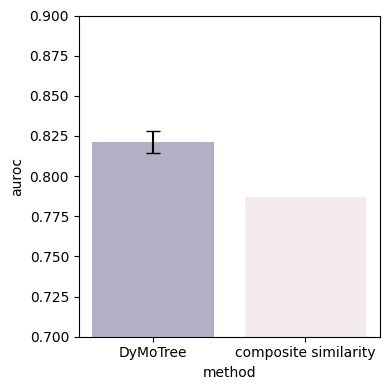

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


metric = 'auroc' 

grouped = res.groupby('method')[metric].agg(['mean', 'std']).reset_index()

colors = ['#A29BB7', '#F2E8E8']  

fig, ax = plt.subplots(figsize=(4,4))
x = np.arange(len(grouped))
ax.bar(
    x,
    grouped['mean'],
    yerr=grouped['std'],
    capsize=5,       
    color=colors[:len(grouped)],
    alpha=0.8
)

ax.set_xticks(x)
ax.set_xticklabels(grouped['method'])
ax.set_xlabel('method')
ax.set_ylabel(metric)

ax.set_ylim(0.7, 0.9)

plt.tight_layout()
#plt.savefig(f"../experiment/prior_compare_LT_auroc.pdf",bbox_inches='tight')
plt.show()

In [ ]:
import sys
import os
import pandas as pd
from pathlib import Path

sys.path.append(os.path.abspath("../src"))
from utils.metrics import calculate_fate_metrics

df1 = pd.read_csv('../experiment/Fig2.bench.lt.csv')
df1 = df1.loc[:,['adata_path','auroc','acc','f1','pearson','spearman']]
df1['adata_path'] = df1['adata_path'].str.extract(r'(day\d+)')
df1['method'] = 'DyMoTree'


methods = ["WOT", "CoSpar", "CellRank", "Palantir", "FateID"]
days = ["day246"]

file_map = {
    "WOT": "wot.res.csv",
    "CoSpar": "cospar.res.csv",
    "CellRank": "cellrank.res.csv",
    "Palantir": "palantir.res.csv",
    "FateID": "fateid.res.csv"
}

base_dir = Path("../experiment/benchmark")

all_res = []

for method in methods:
    for day in days:
        file_path = base_dir / f"LT.{method}" / day / file_map[method]

        if not file_path.exists():
            continue

        res = pd.read_csv(file_path, index_col=0)
        if method == "WOT":
            res["fate_bias"] = res["Monocyte_fate"] / (
                res["Monocyte_fate"] + res["Neutrophil_fate"]
            )
            metric_dict = calculate_fate_metrics(
                y_true_prob=res["Weinreb_fate"],
                y_pred_prob=res["fate_bias"]
            )
        elif method == 'CoSpar':
            metric_dict = calculate_fate_metrics(
                y_true_prob=res["ground_truth"],
                y_pred_prob=1- res["fate_bias_transition_map_Neutrophil*Monocyte"]
            )
        else:
            metric_dict = calculate_fate_metrics(
                y_true_prob=res["ground_truth"],
                y_pred_prob=res["fate_bias"]
            )           
        tmp_df = pd.DataFrame([metric_dict])
        tmp_df["method"] = method
        tmp_df["adata_path"] = day

        all_res.append(tmp_df)

if all_res:
    batch_df = pd.concat(all_res, ignore_index=True)
    df1 = pd.concat([df1, batch_df], ignore_index=True)

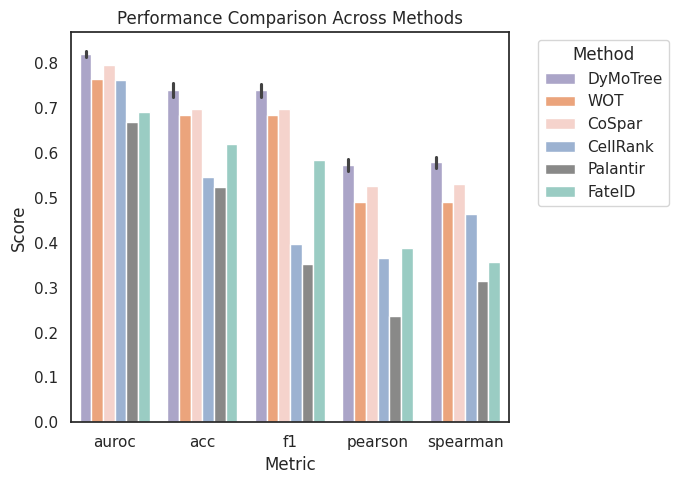

In [ ]:
df_long = df1.melt(
    id_vars=["method"],
    value_vars=["auroc", "acc", "f1", "pearson", "spearman"],
    var_name="metric",
    value_name="value"
)
import seaborn as sns
import matplotlib.pyplot as plt
palette = {
    "DyMoTree": "#A79FCE",  
    "WOT": "#FE9F69",
    "CoSpar": "#FCCFC5",
    "CellRank": "#93B0DA",
    "Palantir": "#898988",
    "FateID": "#91D5C9"
}

sns.set(style="white")

plt.figure(figsize=(7, 5))

sns.barplot(
    data=df_long,
    x="metric",
    y="value",
    hue="method",
    errorbar="sd",
    palette=palette
)

plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("Performance Comparison Across Methods")

plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#plt.savefig(f"../experiment/bench_LT.png",bbox_inches='tight')
plt.show()


In [ ]:
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath("../src"))
import pandas as pd
from pathlib import Path
import scanpy as sc
from dmt import DyMoTree
import pandas as pd

from utils.metrics import calculate_fate_metrics

df1 = pd.read_csv('../experiment/Fig2.bench.CD8.csv')
df1 = df1.loc[:,['adata_path','auroc','acc','f1','pearson','spearman']]
df1['adata_path'] = "CD8"#df1['adata_path'].str.extract(r'(day\d+)')
df1['method'] = 'DyMoTree'

adata = sc.read_h5ad("../data/bench/tcr/anndata/anndata.h5ad")
dmt = DyMoTree(adata=adata,
               k=50,
               progenitor='EE',
               terminal=['TE','MP'],
               lineage_col='lineage',
               emb_key='emb',
               device='cuda',
               seed=1024)
dmt.lineage_graph(mask_threshold=0.8, epsilon=1, mode='composite')

methods = ["wot", "cospar", "CellRank", "Palantir", "FateID"]

file_map = {
    "wot": "wot_res.csv",
    "cospar": "cospar_res.csv",
    "CellRank": "CellRank_res.csv",
    "Palantir": "Palantir_res.csv",
    "FateID": "FateID_res.csv"
}

base_dir = Path('../notebooks/Fig2/2.CD8.DMT.bench.result/')

all_res = []

for method in methods:
    file_path = base_dir /file_map[method]

    if not file_path.exists():
        continue

    res = pd.read_csv(file_path, index_col=0)
    if method in ['wot','cospar']:
        res["fate_bias"] = res["TE_fate"] / (
            res["MP_fate"] + res["TE_fate"]
        )
        metric_dict = calculate_fate_metrics(
            y_true_prob=dmt.get_node('EE',adata_object=True).obs['ground_truth'],
            y_pred_prob=res["fate_bias"]
        )
    elif method in ['CellRank','Palantir']:
        res["fate_bias"] = res["TE"] / (
            res["MP"] + res["TE"]
        )           
        metric_dict = calculate_fate_metrics(
            y_true_prob=dmt.get_node('EE',adata_object=True).obs['ground_truth'],
            y_pred_prob=res["fate_bias"]
        )
    else:
        res["fate_bias"] = res["FI_TE_fate"] / (
            res["FI_MP_fate"] + res["FI_TE_fate"]
        )            
        metric_dict = calculate_fate_metrics(
            y_true_prob=dmt.get_node('EE',adata_object=True).obs['ground_truth'],
            y_pred_prob=res["fate_bias"]
        )           
    tmp_df = pd.DataFrame([metric_dict])
    tmp_df["method"] = method
    tmp_df["adata_path"] = day

    all_res.append(tmp_df)

if all_res:
    batch_df = pd.concat(all_res, ignore_index=True)
    df1 = pd.concat([df1, batch_df], ignore_index=True)


Successfully loaded state: EE, cells: 1084
Successfully loaded state: TE, cells: 2611
Successfully loaded state: MP, cells: 4670
--- Start Building Lineage Graph ---
[*] Intra-state graph built for 'EE' (Edges: 53116)
[*] Intra-state graph built for 'TE' (Edges: 127939)
[*] Intra-state graph built for 'MP' (Edges: 228830)
[*] Calculating composite similarity between progenitor 'EE' and terminals ['TE', 'MP']...
[*] Inter-state graph built for 'TE' (Edges: 734733)
[*] Inter-state graph built for 'MP' (Edges: 1032263)


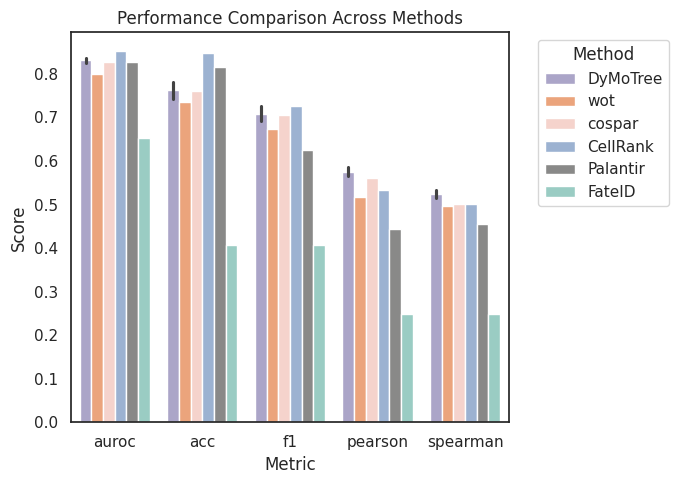

In [ ]:

df_long = df1.melt(
    id_vars=["method"],
    value_vars=["auroc", "acc", "f1", "pearson", "spearman"],
    var_name="metric",
    value_name="value"
)
import seaborn as sns
import matplotlib.pyplot as plt
palette = {
    "DyMoTree": "#A79FCE",  
    "wot": "#FE9F69",
    "cospar": "#FCCFC5",
    "CellRank": "#93B0DA",
    "Palantir": "#898988",
    "FateID": "#91D5C9"
}

sns.set(style="white")

plt.figure(figsize=(7, 5))

sns.barplot(
    data=df_long,
    x="metric",
    y="value",
    hue="method",
    errorbar="sd",
    palette=palette
)

plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("Performance Comparison Across Methods")

plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#plt.savefig(f"../experiment/bench_CD8.pdf",bbox_inches='tight')
plt.show()
